In [12]:
import pandas as pd
import os

In [22]:
cwd= os.getcwd()
print(cwd)
BASE_DIR= os.path.join(cwd,"..")

data= os.path.join(BASE_DIR, "data", "concat_for_eda.csv")

/home/hngoc/thesis/microcytic-reduced/notebooks


In [23]:
df= pd.read_csv(data)
# df= pd.read_excel(data)
print(df)
print(df.shape)

        Hb   MCV   Fe  Ferritin  Transferin   TSAT (%)    CRP Chẩn đoán  \
0     86.0  76.6  3.1    1062.0       170.0   2.852014  174.8  ACD, IDA   
1    114.0  78.5  2.2     457.0       145.0   8.476209   15.3       ACD   
2     84.0  75.5  2.6     445.3        93.0  15.618430  120.1       ACD   
3    115.0  79.6  1.7    1151.0       125.0   7.597765    9.9       ACD   
4     90.0  57.3  2.9    2009.0       116.0  46.263966   62.9       ACD   
..     ...   ...  ...       ...         ...        ...    ...       ...   
146   57.0  55.9  2.1      87.0       351.0   3.342406    NaN       IDA   
147   57.0  68.1  2.5      44.0       311.0   4.490830    NaN       IDA   
148   42.0  60.3  2.3       5.1         NaN        NaN    NaN       IDA   
149   68.0  62.6  2.3       9.6         NaN        NaN    NaN       IDA   
150   40.0  73.9  1.6      54.0       370.0   2.415824    NaN       IDA   

     Tiền sử hoặc bệnh kèm theo  Tuổi  ...  HbE  Hb khác  \
0                          True   NaN  

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hb                          151 non-null    float64
 1   MCV                         151 non-null    float64
 2   Fe                          129 non-null    float64
 3   Ferritin                    127 non-null    float64
 4   Transferin                  54 non-null     float64
 5   TSAT (%)                    62 non-null     float64
 6   CRP                         64 non-null     float64
 7   Chẩn đoán                   148 non-null    object 
 8   Tiền sử hoặc bệnh kèm theo  151 non-null    bool   
 9   Tuổi                        110 non-null    float64
 10  RBC                         105 non-null    float64
 11  MCH                         28 non-null     float64
 12  MCHC                        111 non-null    float64
 13  RDW-CV                      101 non

### Univariable Distribution

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df_copy= df.copy()

X_y_don= df_copy.drop(columns= ["ACD", "IDA", "Thal"])


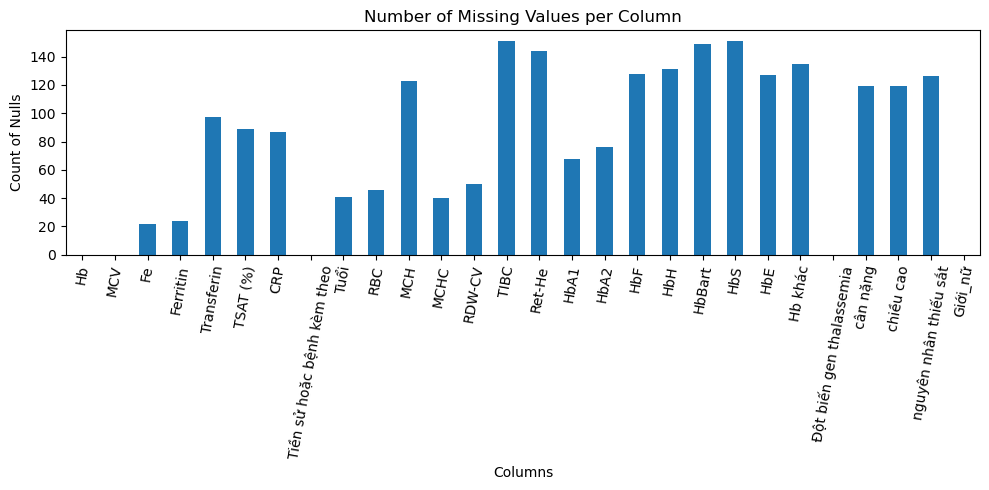

In [17]:
null_X = X_y_don.drop(columns= ["Chẩn đoán"])
null_counts = null_X.isnull().sum()

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
null_counts.plot(kind='bar')

# Xoay trục x 45 độ
plt.xticks(rotation=80)

plt.title('Number of Missing Values per Column')
plt.xlabel('Columns')
plt.ylabel('Count of Nulls')

plt.tight_layout()
plt.show()

In [ ]:
for i in range(len(X_y_don)):
    col_name= X_y_don.columns[i]
    plt.figure()
    sns.boxplot(data= X_y_don, x=col_name, hue= "Chẩn đoán")
    plt.legend(
    title= f"Univariable distribution of {col_name} following diagnoses",
    bbox_to_anchor=(1.05, 1),  # đẩy sang phải
    loc='upper left'
)
    plt.show()

In [ ]:
"""
df["Decision_Class_Label"] = df["Decision_Class"].map({0: "healthy", 1: "anemia"})
sns.countplot(data=df, x="Decision_Class_Label")
plt.xlabel("Diagnosis")
plt.ylabel("Samples")
"""

In [ ]:
plt.figure()
sns.countplot(data= X_y_don, x= "Giới_Nữ", hue= "Chẩn đoán")
plt.legend(
    title= "Univariable distribution of gender following diagnoses",
    bbox_to_anchor=(1.05, 1),  # đẩy sang phải
    loc='upper left'
)

In [ ]:
# làm cái này với điều kiện no null values

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = X_y_don.drop("Chẩn đoán", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=X_y_don["Chẩn đoán"])

In [ ]:
from sklearn.manifold import TSNE

X = df.drop("Diagnosis", axis=1)
X_embedded = TSNE(n_components=2).fit_transform(X)

plt.figure()
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=df["Diagnosis"])
plt.legend(
    title="Diagnosis",
    bbox_to_anchor=(1.05, 1),  # đẩy sang phải
    loc='upper left'
)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_embedded, df["Diagnosis"])
print(score)

In [ ]:
plt.figure()

ax = sns.kdeplot(
    x=X_embedded[:,0],
    y=X_embedded[:,1],
    hue=df["Diagnosis"]
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X_scaled)

sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=clusters)

In [ ]:
df.groupby("Diagnosis")["LYMp"].describe()

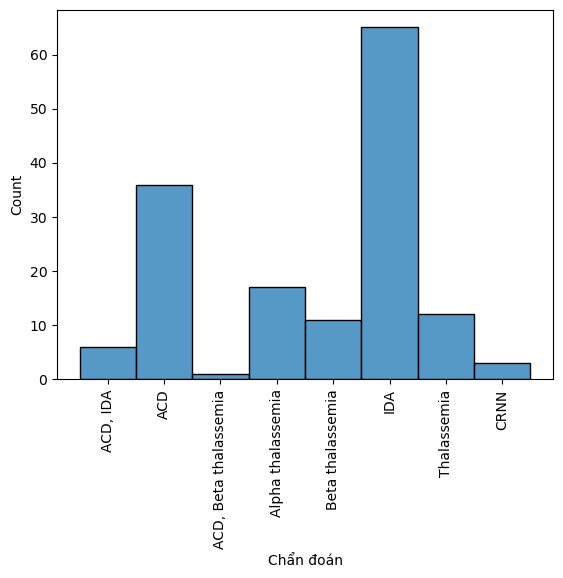

In [24]:
#sns.histplot(cleaned_df["Chẩn đoán (chỉ liên quan hồng cầu nhỏ: IDA, ACD, Thalassemia, CRNN)"])
sns.histplot(df["Chẩn đoán"])
plt.xticks(rotation=90)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

"""
def combine_images(img_paths):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, img_path in zip(axes, img_paths):
        img = plt.imread(img_path)
        ax.imshow(img)
        ax.axis("off")  # tắt trục cho đẹp

    return fig
"""
save_dir= os.path.join(BASE_DIR, "notebooks", "png")
pr_paths= [os.path.join(save_dir, "pr_curve_rf.png"), os.path.join(save_dir, "pr_curve_xgb.png"), os.path.join(save_dir, "pr_curve_lgbm.png")]
roc_paths= [os.path.join(save_dir, "roc_auc_rf.png"), os.path.join(save_dir, "roc_auc_xgb.png"), os.path.join(save_dir, "roc_auc_lgbm.png")]



In [ ]:
#combined_pr_fig = combine_images(pr_paths)


In [ ]:
#combined_roc_fig = combine_images(roc_paths)

In [ ]:
    
data_shap= os.path.join(BASE_DIR, "data", "test_data.csv")

df_shap= pd.read_csv(data_shap)

X = df_shap.drop(columns=["ACD", "IDA", "Thal"])
y = df_shap[["ACD", "IDA", "Thal"]]


In [ ]:
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import joblib

def plot_multi_roc(models_dict, y_true, X_test):
    labels = y_true.columns.tolist()  # ["ACD", "IDA", "Thal"]
    
    figs = {}

    for i, label in enumerate(labels):
        fig, ax = plt.subplots()

        for name, path in models_dict.items():
            model = joblib.load(path)
            y_probs = model.predict_proba(X_test)

            y_prob = y_probs[i][:, 1]   # lấy class 1 của label i
            y_true_label = y_true.iloc[:, i]

            fpr, tpr, _ = roc_curve(y_true_label, y_prob)
            roc_auc = auc(fpr, tpr)

            ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

        ax.plot([0, 1], [0, 1], linestyle="--")
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        ax.set_title(f"ROC Curve - {label}")
        ax.legend()

        figs[label] = fig

    return figs


from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_multi_pr(models_dict, y_true, X_test):
    labels = y_true.columns.tolist()
    
    figs = {}

    for i, label in enumerate(labels):
        fig, ax = plt.subplots()

        for name, path in models_dict.items():
            model = joblib.load(path)
            y_probs = model.predict_proba(X_test)

            y_prob = y_probs[i][:, 1]
            y_true_label = y_true.iloc[:, i]

            precision, recall, _ = precision_recall_curve(y_true_label, y_prob)
            ap = average_precision_score(y_true_label, y_prob)

            ax.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_title(f"PR Curve - {label}")
        ax.legend()

        figs[label] = fig

    return figs

In [ ]:
models = {
    "RF": os.path.join(BASE_DIR, "artifacts", "RF_best_model.pkl"),
    "XGBoost": os.path.join(BASE_DIR, "artifacts", "XGBoost_best_model.pkl"),
    "LightGBM": os.path.join(BASE_DIR, "artifacts", "LightGBM_best_model.pkl")
}

fig_roc = plot_multi_roc(models, y, X)
fig_pr = plot_multi_pr(models, y, X)

In [ ]:
fig_pr = plot_multi_pr(models, y, X)
display(fig_pr)

In [ ]:
fig_roc = plot_multi_roc(models, y, X)
display(fig_roc)

In [25]:
y = df[["ACD", "IDA", "Thal"]]

counts = y.value_counts()

print(counts)

ACD  IDA  Thal
0    1    0       65
     0    1       40
1    0    0       36
     1    0        6
0    0    0        3
1    0    1        1
Name: count, dtype: int64
